## Load data

In [1]:
import re
import numpy as np
import pandas as pd

DATA_FOLDER = "/kaggle/input/competitions/smart-mcq-solver-challenge/"
OPTIONS = ["A", "B", "C", "D", "E"]
LETTER_TO_INDEX = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
SEED = 42
VALIDATION_FRACTION = 0.20

np.random.seed(SEED)

train_df = pd.read_csv(DATA_FOLDER + "train.csv")
test_df = pd.read_csv(DATA_FOLDER + "test.csv")

print("train rows:", len(train_df))
print("test rows :", len(test_df))

train rows: 2000
test rows : 500


In [2]:
train_df.head(3)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


## Basic checks

In [3]:
print("train rows :", len(train_df))
print("test rows  :", len(test_df))
print("columns    :", list(train_df.columns))
print()
print("missing values in train:", train_df.isna().sum().sum())
print("missing values in test :", test_df.isna().sum().sum())

train rows : 2000
test rows  : 500
columns    : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']

missing values in train: 0
missing values in test : 0


## Clean the prompts

Every prompt has extra filler text. Removing it.

In [4]:
PREFIXES = [
    "Pick the best possible answer:",
    "Select the most accurate option:",
    "Identify the correct statement:",
    "Determine the correct option:",
    "Choose the correct answer:",
    "Which of the following is correct?",
]

SUFFIXES = [
    "among the listed options.",
    "from the following choices.",
    "carefully.",
    "based on the given context.",
    "among the list of options.",
]


def clean_prompt(text):
    text = str(text).strip()

    for prefix in PREFIXES:
        if text.startswith(prefix):
            text = text[len(prefix):]
            text = text.strip()
            break

    for suffix in SUFFIXES:
        if text.endswith(suffix):
            text = text[:-len(suffix)]
            text = text.strip()
            break

    return text


train_df["question"] = train_df["prompt"].apply(clean_prompt)
test_df["question"] = test_df["prompt"].apply(clean_prompt)

y_all = train_df["answer"].map(LETTER_TO_INDEX).values

print("before:", train_df["prompt"].iloc[0][:90])
print("after :", train_df["question"].iloc[0][:90])

before: Pick the best possible answer: What is Martin Heidegger's view on the relationship between
after : What is Martin Heidegger's view on the relationship between time and human existence?


## Answer distribution

In [5]:
answer_counts = train_df["answer"].value_counts().reindex(OPTIONS)

print(answer_counts.to_string())
print()
print("most common answer :", answer_counts.idxmax())
print("least common answer:", answer_counts.idxmin())

answer
A    369
B    490
C    459
D    358
E    324

most common answer : B
least common answer: E


## Lengths

In [6]:
question_lengths = train_df["question"].astype(str).str.len()

option_lengths = []
for letter in OPTIONS:
    option_lengths.append(train_df[letter].astype(str).str.len())
option_lengths = np.column_stack(option_lengths)

print("question length: mean", int(question_lengths.mean()),
      " min", question_lengths.min(), " max", question_lengths.max())
print("option length  : mean", int(option_lengths.mean()),
      " min", option_lengths.min(), " max", option_lengths.max())

question length: mean 72  min 19  max 277
option length  : mean 164  min 1  max 662


## Correct vs wrong option length

In [7]:
correct_lengths = []
wrong_lengths = []

for row_number in range(len(train_df)):
    correct_option = y_all[row_number]
    for option_number in range(5):
        if option_number == correct_option:
            correct_lengths.append(option_lengths[row_number, option_number])
        else:
            wrong_lengths.append(option_lengths[row_number, option_number])

print("average length of the CORRECT option:", int(np.mean(correct_lengths)))
print("average length of the WRONG options :", int(np.mean(wrong_lengths)))

longest = option_lengths.argmax(axis=1)
print()
print("the answer is the longest option in",
      round((longest == y_all).mean() * 100, 1), "% of questions")
print("random guessing would give 20 %")

average length of the CORRECT option: 181
average length of the WRONG options : 160

the answer is the longest option in 40.6 % of questions
random guessing would give 20 %


The correct option is longer on average. The wrong options were made by rewriting the correct one, so they came out shorter.

## Duplicate questions

In [8]:
def normalize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.strip()


def make_question_key(row):
    option_texts = []
    for letter in OPTIONS:
        option_texts.append(normalize(row[letter]))
    option_texts.sort()
    return "|".join(option_texts)


train_df["key"] = train_df.apply(make_question_key, axis=1)

key_counts = train_df["key"].value_counts()

print("total rows        :", len(train_df))
print("unique questions  :", train_df["key"].nunique())
print("questions repeated:", (key_counts > 1).sum())
print("rows in repeats   :", key_counts[key_counts > 1].sum())

total rows        : 2000
unique questions  : 588
questions repeated: 210
rows in repeats   : 1622


Many questions repeat. So the train/validation split must keep all copies of a question on the same side.

## Plots

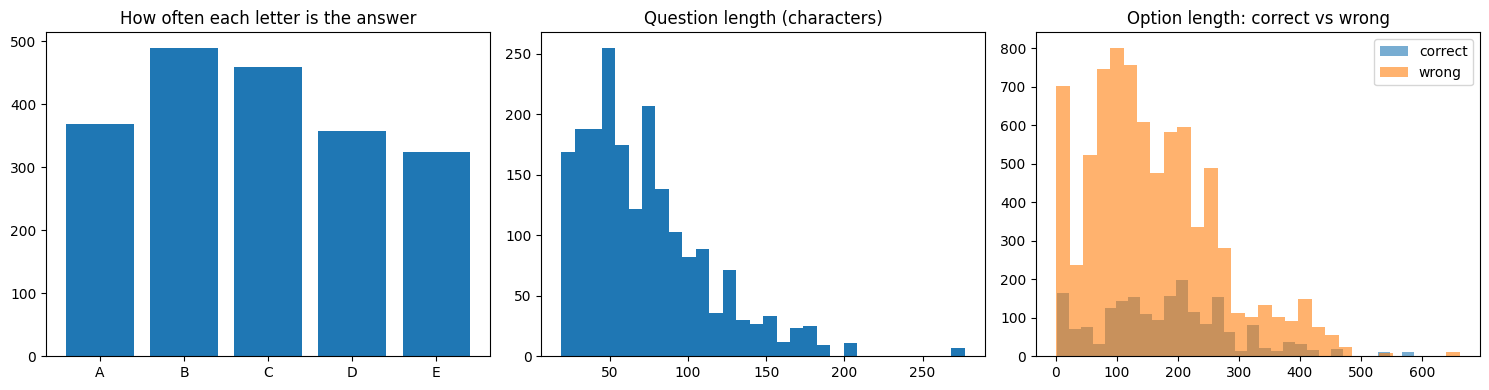

In [9]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(answer_counts.index, answer_counts.values)
axes[0].set_title("How often each letter is the answer")

axes[1].hist(question_lengths, bins=30)
axes[1].set_title("Question length (characters)")

axes[2].hist(correct_lengths, bins=30, alpha=0.6, label="correct")
axes[2].hist(wrong_lengths, bins=30, alpha=0.6, label="wrong")
axes[2].set_title("Option length: correct vs wrong")
axes[2].legend()

plt.tight_layout()
plt.show()

## Summary

- 2000 train rows, 500 test rows, no missing values
- All five letters used fairly evenly
- Correct option is longer than the wrong ones
- Many duplicate questions, so the split must be grouped